Índice de Qualidade do Ar (AQI) para São Paulo: 160
Poluentes detectados: {'co': {'v': 9.1}, 'h': {'v': 77}, 'no2': {'v': 19.7}, 'o3': {'v': 28.1}, 'p': {'v': 997}, 'pm10': {'v': 74}, 'pm25': {'v': 160}, 'so2': {'v': 5.1}, 't': {'v': 21}, 'w': {'v': 3.6}}


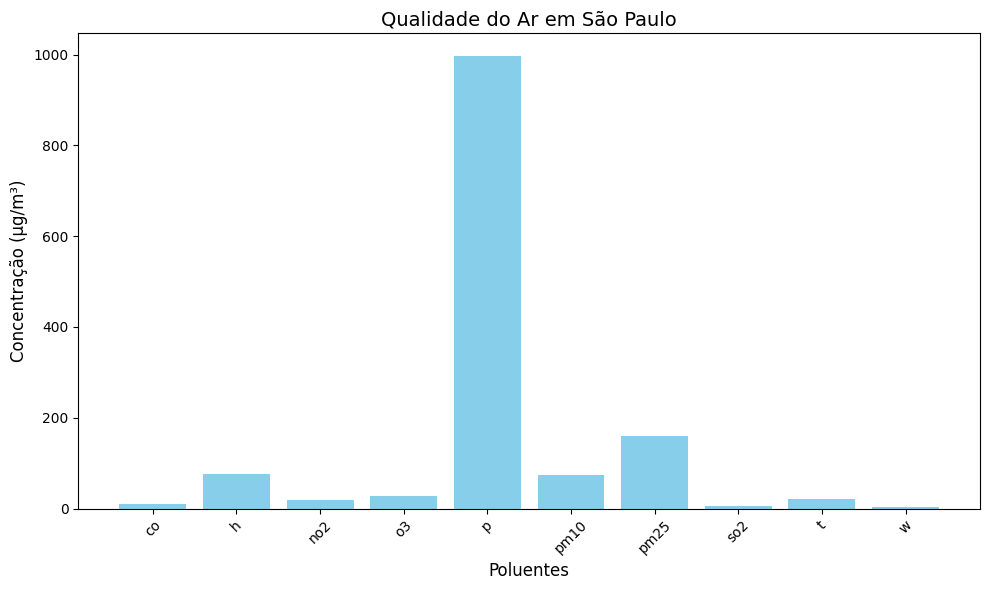

In [5]:
import requests
import matplotlib.pyplot as plt

# Nome da cidade e a URL da API
cidade = "São Paulo"
url = f"http://api.waqi.info/feed/{cidade}/?token=demo"

# Fazendo a requisição para a API
try:
    response = requests.get(url)
    response.raise_for_status()  # Levanta um erro se a resposta for inválida
    dados = response.json()

    if dados["status"] == "ok":
        # Obtendo os dados relevantes
        aqi = dados["data"]["aqi"]  # Índice de Qualidade do Ar
        poluicao = dados["data"]["iaqi"]

        print(f"Índice de Qualidade do Ar (AQI) para {cidade}: {aqi}")
        print(f"Poluentes detectados: {poluicao}")

        # Preparando a visualização gráfica
        poluentes = poluicao.keys()
        valores = [poluicao[p]["v"] for p in poluentes]

        # Visualização gráfica com Matplotlib
        plt.figure(figsize=(10, 6))
        plt.bar(poluentes, valores, color='skyblue')
        plt.title(f"Qualidade do Ar em {cidade}", fontsize=14)
        plt.xlabel('Poluentes', fontsize=12)
        plt.ylabel('Concentração (µg/m³)', fontsize=12)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    else:
        print("Não foi possível obter dados sobre a qualidade do ar.")

except requests.exceptions.RequestException as e:
    print(f"Erro ao obter dados: {e}")
